## Removing the details: denoising a 1D signal

It holds that: 
> **large coefficients = signal, small coefficients = noise.**

Throwing away the small coefficients (*thresholding*) removes most of the noise and almost none
of the signal.

In [1]:
# the KMP setting avoids a clash between the OpenMP runtimes of FMCA and numpy
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import numpy as np
import matplotlib.pyplot as plt
import FMCA

plt.rcParams.update({
    "figure.dpi": 80,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C_DATA, C_SAMP, C_REF = "#1f4e79", "#c1121f", "#2a9d8f"

## A noisy signal

noise level sigma = 0.15,  relative error of the noisy data = 0.1621


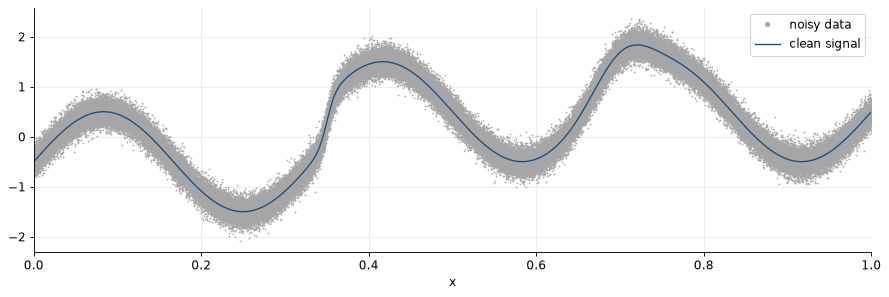

In [2]:
N, dtilde = 100000, 4

def signal(t):
    return (np.sin(6 * np.pi * t)
            + 0.5 * np.tanh(100 * (t - 0.35))
            + 0.6 * np.exp(-500 * (t - 0.7) ** 2))

pts = np.linspace(0, 1, N).reshape(1, N)
ST = FMCA.SampletTree(pts, dtilde)
x = ST.toClusterOrder(pts.T).ravel()

clean = signal(x)
sigma = 0.15
noisy = clean + sigma * np.random.randn(N)

err0 = np.linalg.norm(noisy - clean) / np.linalg.norm(clean)
print(f"noise level sigma = {sigma},  relative error of the noisy data = {err0:.4f}")

plt.figure(figsize=(11, 3.6))
plt.plot(x, noisy, ".", ms=1.2, color="0.65", label="noisy data")
plt.plot(x, clean, "-", lw=1.2, color=C_DATA, label="clean signal")
plt.legend(markerscale=6)
plt.xlim(0, 1)
plt.xlabel("x")
plt.show()

## Noise does not concentrate

Compare the sorted coefficient magnitudes of the clean and the noisy signal. Below a level of
roughly $\sigma$ the noisy curve flattens out into a plateau &mdash; that plateau *is* the noise.

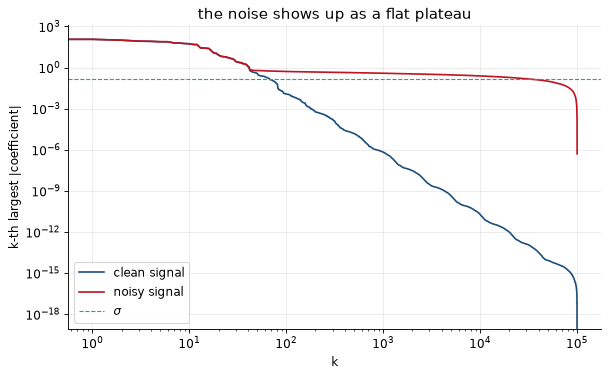

In [3]:
c_clean = ST.sampletTransform(clean).ravel()
c_noisy = ST.sampletTransform(noisy).ravel()

plt.figure(figsize=(7.5, 4.6))
plt.loglog(np.sort(np.abs(c_clean))[::-1], color=C_DATA, label="clean signal")
plt.loglog(np.sort(np.abs(c_noisy))[::-1], color=C_SAMP, label="noisy signal")
plt.axhline(sigma, ls="--", lw=1, color=C_REF, label=r"$\sigma$")
plt.xlabel("k")
plt.ylabel("k-th largest |coefficient|")
plt.title("the noise shows up as a flat plateau")
plt.legend()
plt.show()

## Hard and soft thresholding

With $N$ coefficients and noise level $\sigma$, the classical *universal* (VisuShrink) threshold is

$$\lambda = \sigma\sqrt{2\log N},$$

the expected maximum of $N$ standard normal variables &mdash; so with high probability every
pure-noise coefficient falls below it. The scaling coefficients (the coarse mean of the signal)
are always kept.

universal threshold lambda = 0.7198


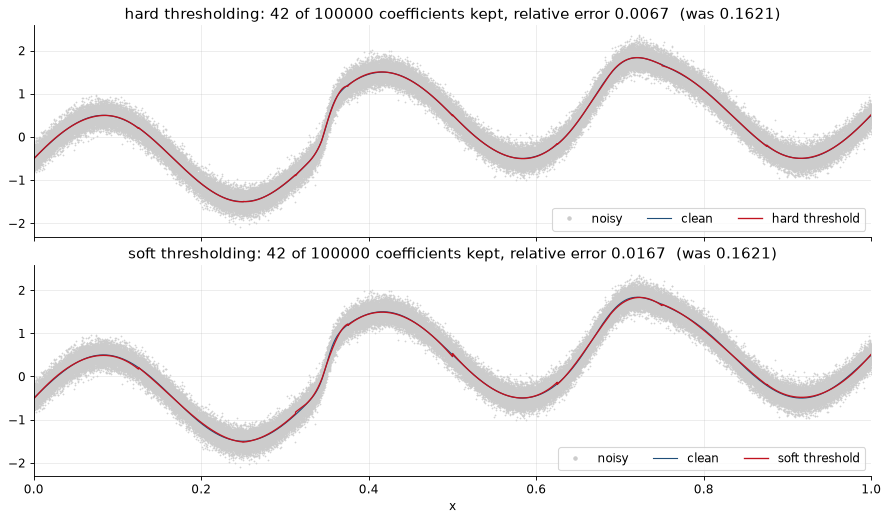

In [4]:
lam = sigma * np.sqrt(2 * np.log(N))
print(f"universal threshold lambda = {lam:.4f}")

def denoise(coeffs, lam, mode="hard", nkeep=0):
    if mode == "hard":
        out = np.where(np.abs(coeffs) > lam, coeffs, 0.0)
    else:
        out = np.sign(coeffs) * np.maximum(np.abs(coeffs) - lam, 0.0)
    out[:nkeep] = coeffs[:nkeep]          # never touch the scaling coefficients
    rec = ST.inverseSampletTransform(out).ravel()
    return rec, int((out != 0).sum())

fig, ax = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
for a, mode in zip(ax, ["hard", "soft"]):
    rec, nz = denoise(c_noisy, lam, mode, ST.nscalfs())
    e = np.linalg.norm(rec - clean) / np.linalg.norm(clean)
    a.plot(x, noisy, ".", ms=1.0, color="0.8", label="noisy")
    a.plot(x, clean, "-", lw=1.0, color=C_DATA, label="clean")
    a.plot(x, rec, "-", lw=1.2, color=C_SAMP, label=f"{mode} threshold")
    a.set_title(f"{mode} thresholding: {nz} of {N} coefficients kept, "
                f"relative error {e:.4f}  (was {err0:.4f})")
    a.legend(markerscale=6, loc="lower right", ncols=3)
ax[1].set_xlabel("x")
ax[1].set_xlim(0, 1)
plt.show()